# California Yoga Studio Reviews
## Notebook 4: Sentiment Analysis (VADER)
*2026-05*

This notebook applies VADER (Valence Aware Dictionary and sEntiment Reasoner)
sentiment analysis to 10,547 yoga studio reviews that contain text. Sentiment
scores are computed at review level, classified into positive, neutral, and
negative categories, and aggregated to studio level for downstream analysis.

VADER was chosen because it is specifically designed for social media and
user-generated text, handling informal language, punctuation emphasis, and
emoji — all common in Google Reviews.

**Input:** `yoga_studios_meta.pkl`, `yoga_reviews.pkl`
**Output:** `yoga_reviews_sentiment.pkl`, `yoga_studios_meta.pkl` (updated
with studio-level sentiment aggregates)




## Setup

In [ ]:
# install vaderSentiment
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Load data

Load the full review dataset and filter to reviews with text only.
Rating-only reviews (3,391) are excluded from sentiment analysis
but retained in the original file for the classifier.

In [ ]:
# mount google drive
drive.mount('/content/gdrive', force_remount=True)

PROJECT_DIR = '/content/gdrive/MyDrive/YogaStudioReviews'

yoga_meta = pd.read_pickle(os.path.join(PROJECT_DIR, 'yoga_studios_meta.pkl'))
yoga_reviews = pd.read_pickle(os.path.join(PROJECT_DIR, 'yoga_reviews.pkl'))

# Work only with reviews that have text
reviews_text = yoga_reviews[yoga_reviews['text'].notna()].copy()

print(f'Loaded {len(yoga_meta)} studios and {len(yoga_reviews):,} reviews')
print(f'Reviews with text for sentiment analysis: {len(reviews_text):,}')

Mounted at /content/gdrive
Loaded 423 studios and 13,938 reviews
Reviews with text for sentiment analysis: 10,547


## VADER sentiment scoring

VADER assigns four scores to each review:
- `pos` — proportion of text with positive sentiment
- `neg` — proportion of text with negative sentiment
- `neu` — proportion of text with neutral sentiment
- `compound` — normalised aggregate score ranging from -1 (most negative)
  to +1 (most positive)

The compound score is the primary metric used throughout this analysis.

In [ ]:
analyzer = SentimentIntensityAnalyzer()

# Apply VADER to every review — this may take a minute
print('Running VADER sentiment analysis...')
reviews_text['vader_scores'] = reviews_text['text'].apply(
    lambda text: analyzer.polarity_scores(text)
)

# Unpack the four scores into separate columns
reviews_text['vader_pos']      = reviews_text['vader_scores'].apply(lambda s: s['pos'])
reviews_text['vader_neg']      = reviews_text['vader_scores'].apply(lambda s: s['neg'])
reviews_text['vader_neu']      = reviews_text['vader_scores'].apply(lambda s: s['neu'])
reviews_text['vader_compound'] = reviews_text['vader_scores'].apply(lambda s: s['compound'])

# Drop the raw scores dict — no longer needed
reviews_text = reviews_text.drop(columns=['vader_scores'])

print('Done.')
print(f'\nSample VADER scores:')
print(reviews_text[['text', 'rating', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu']].head(5).to_string())

Running VADER sentiment analysis...
Done.

Sample VADER scores:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                text  rating  vader_compound  vader_pos  vader_neg  vader_neu
0                                                                                                                                                                                                         

### Sample output validation

The first four reviews are 5-star with compound scores above 0.97 —
VADER correctly identifies the strongly positive language. Review 4
is a 1-star with compound -0.572, correctly flagging "DO NOT GO HERE"
and "scam" as negative.

Note that all four positive sample reviews are from the same studio
(iYoga Transformation, instructor Benny) — a reminder that reviews
cluster at studio level, which is accounted for in the studio-level
aggregation step.


## Sentiment classification

Each review is classified using standard VADER compound score thresholds:
- `compound ≥ 0.05` → positive
- `compound ≤ -0.05` → negative
- between → neutral

In [ ]:
# Classify using standard VADER thresholds
# compound >= 0.05 → positive
# compound <= -0.05 → negative
# between → neutral

def classify_sentiment(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

reviews_text['sentiment'] = reviews_text['vader_compound'].apply(classify_sentiment)

print('=== Sentiment distribution ===')
counts = reviews_text['sentiment'].value_counts()
for sentiment, count in counts.items():
    pct = count / len(reviews_text) * 100
    print(f'  {sentiment:<10} {count:>6,}  ({pct:.1f}%)')

=== Sentiment distribution ===
  positive   10,108  (95.8%)
  negative      295  (2.8%)
  neutral       144  (1.4%)


In [ ]:
# How many 'positive' reviews are under 20 characters?
short_positive = reviews_text[
    (reviews_text['sentiment'] == 'positive') &
    (reviews_text['text_length'] < 20)
]
print(f'Short positive reviews (under 20 chars): {len(short_positive):,}')
print(f'As % of all positive: {len(short_positive)/len(reviews_text[reviews_text["sentiment"]=="positive"])*100:.1f}%')
print(f'\nSample short positive reviews:')
print(short_positive['text'].value_counts().head(10).to_string())

Short positive reviews (under 20 chars): 195
As % of all positive: 1.9%

Sample short positive reviews:
text
Love this place!      8
Amazing               3
Amazing!              3
Love this studio!     2
Amazing experience    2
Great experience!     2
Love this place       2
Awesome place         2
Great place           2
Great studio!         2


### Insight — 95.8% of reviews are classified as positive

The strong positivity bias is consistent with the rating distribution —
yoga studio customers are a demographic who tend to leave enthusiastic reviews. The 2.8% negative corpus (295 reviews) is small but analytically valuable, containing the strongest signal about what goes wrong at yoga studios.

**Known VADER limitation:** very short reviews ("Great!", "Amazing") score above the 0.05 threshold and are classified as positive despite carrying minimal semantic content. A check confirmed only 195 such reviews (1.9% of positive) — minimal impact on the further analysis.

## Sentiment vs star rating

Does VADER compound score align with star ratings? Higher compound scores for higher-rated reviews are expected but the relationship need to be confirmed.

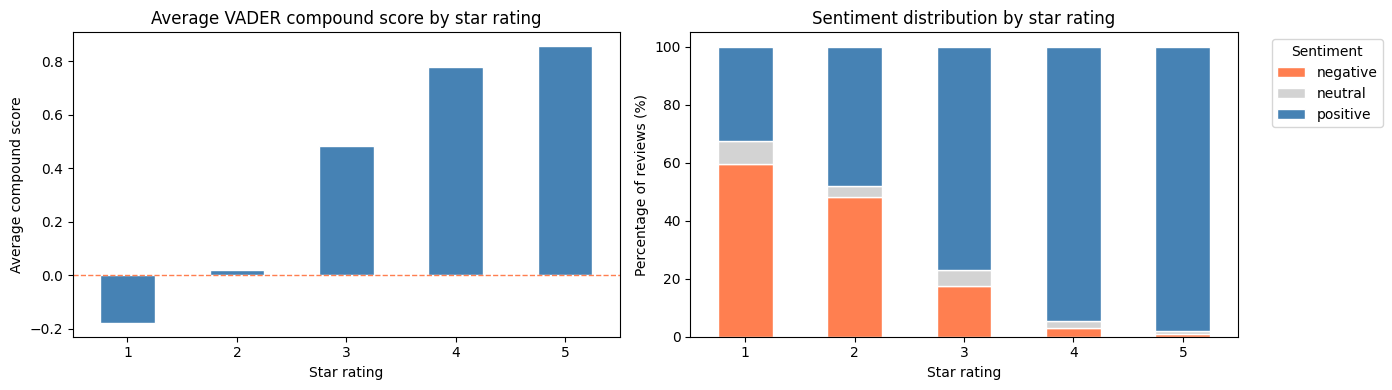

=== Average VADER compound score by rating ===
rating
1   -0.177
2    0.020
3    0.483
4    0.778
5    0.857


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Average compound score by star rating
avg_compound = reviews_text.groupby('rating')['vader_compound'].mean()
avg_compound.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average VADER compound score by star rating')
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Average compound score')
axes[0].axhline(0, color='coral', linestyle='--', linewidth=1)
axes[0].tick_params(axis='x', rotation=0)

# 2. Sentiment class distribution by star rating
sentiment_by_rating = reviews_text.groupby(['rating', 'sentiment']).size().unstack(fill_value=0)
sentiment_by_rating_pct = sentiment_by_rating.div(sentiment_by_rating.sum(axis=1), axis=0) * 100
sentiment_by_rating_pct.plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['coral', 'lightgray', 'steelblue'],
    edgecolor='white'
)
axes[1].set_title('Sentiment distribution by star rating')
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Percentage of reviews (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

print('=== Average VADER compound score by rating ===')
print(avg_compound.round(3).to_string())

### Insight — VADER sentiment aligns strongly with star ratings but low ratings are milder than expected

VADER compound scores increase consistently with star rating, confirming that sentiment analysis captures meaningful signal from yoga studio reviews.

Notably, 1-star reviews average only mildly negative (-0.177)
and 2-star reviews are nearly neutral (+0.020). Dissatisfied
customers tend to use measured, descriptive language rather than
strongly emotional language. This is consistent with the finding that
negative reviews are significantly longer and more detailed.

**Implication for NLP:** the classifier will need to rely on
content and context rather than emotional intensity alone to
distinguish low from high ratings.

## Sentiment-rating mismatches

This section explores cases where VADER and star rating disagree — 5-star reviews with negative sentiment scores and 1-star reviews with positive scores.

In [ ]:
# Mismatches — high rating but negative sentiment
high_rating_neg = reviews_text[
    (reviews_text['rating'] == 5) &
    (reviews_text['sentiment'] == 'negative')
]

# Low rating but positive sentiment
low_rating_pos = reviews_text[
    (reviews_text['rating'] == 1) &
    (reviews_text['sentiment'] == 'positive')
]

print(f'5-star reviews with negative VADER sentiment: {len(high_rating_neg):,}')
print(f'1-star reviews with positive VADER sentiment: {len(low_rating_pos):,}')

print('\nSample 5-star negative sentiment reviews:')
for _, row in high_rating_neg[['text', 'vader_compound']].head(5).iterrows():
    print(f'\n  Compound: {row["vader_compound"]:.3f}')
    print(f'  Text: "{row["text"][:150]}..."')

print('\nSample 1-star positive sentiment reviews:')
for _, row in low_rating_pos[['text', 'vader_compound']].head(5).iterrows():
    print(f'\n  Compound: {row["vader_compound"]:.3f}')
    print(f'  Text: "{row["text"][:150]}..."')

5-star reviews with negative VADER sentiment: 73
1-star reviews with positive VADER sentiment: 80

Sample 5-star negative sentiment reviews:

  Compound: -0.477
  Text: "Went there for 4 years. Moved to Idaho. 😢..."

  Compound: -0.680
  Text: "Can't say enough good things about Dr. Tinsley and her staff! I no longer have chronic pain in my hip and she truly balances the whole body!..."

  Compound: -0.389
  Text: "Incredible neighborhood studio. No frills/non-corporate. Amazing teachers with classes ranging from fast-paced vinyasa, to yin, to fundamentals. This ..."

  Compound: -0.296
  Text: "Look no further..."

  Compound: -0.420
  Text: "This place is more than just a yoga studio, it's a community. Even if you're just looking for a chill place to hangout and study, the Art Of Living St..."

Sample 1-star positive sentiment reviews:

  Compound: 0.300
  Text: "THE OWNER SUCKS!! MOST THE TEACHERS ARE COOL, BUT I'LL GO TO A BETTER STUDIO... A WASTE OF MONEY!!!..."

  Compound: 0.876

### Insight — VADER mismatches reveal limitations

73 five-star reviews scored negatively and 80 one-star reviews scored
positively by VADER — together 1.4% of all text reviews.

**Why 5-star reviews score negative:**
VADER missinterprets phrases such as "can't say enough good things",
farewell sentiment "Moved to Idaho 😢", and informal praise phrases
"no frills", "look no further" — all of which contain words VADER
interprets as negative falsely.

**Why 1-star reviews score positive:**
VADER misses sarcasm, complaint narratives that open with positive
anticipation before describing disappointment, and critique
written in non-emotional language.

**Implication:** VADER is reliable for clearly positive reviews (95.8%
of our dataset) but slightly less reliable at the extremes. For the classifier,
VADER compound score will be a useful feature but should be combined
with other signals rather than used alone.

## Studio-level sentiment aggregation

Individual review sentiment is aggregated to studio level to produce
more stable and reliable sentiment signals. Studio-level averages
smooth out individual reviewer noise and reveal the underlying
relationship between sentiment and studio quality more clearly.

In [ ]:
# Drop existing sentiment columns if re-running to avoid merge conflicts
cols_to_drop = ['mean_compound', 'pct_positive', 'pct_negative', 'review_count']
yoga_meta = yoga_meta.drop(columns=[c for c in cols_to_drop if c in yoga_meta.columns])

# Aggregate sentiment to studio level and merge with metadata
studio_sentiment = reviews_text.groupby('gmap_id').agg(
    mean_compound=('vader_compound', 'mean'),
    pct_positive=('sentiment', lambda x: (x == 'positive').sum() / len(x) * 100),
    pct_negative=('sentiment', lambda x: (x == 'negative').sum() / len(x) * 100),
    review_count=('vader_compound', 'count')
).reset_index()

yoga_meta = yoga_meta.merge(studio_sentiment, on='gmap_id', how='left')

print('=== Studio-level sentiment summary ===')
print(f'Mean compound score across all studios: {yoga_meta["mean_compound"].mean():.3f}')
print(f'Most positive studio: {yoga_meta.nlargest(1, "mean_compound")[["name", "mean_compound"]].values[0]}')
print(f'Most negative studio: {yoga_meta.nsmallest(1, "mean_compound")[["name", "mean_compound"]].values[0]}')

corr, p_val = stats.spearmanr(
    reviews_text['vader_compound'].dropna(),
    reviews_text['rating'].dropna()
)
print(f'\nSpearman correlation — compound score vs star rating: {corr:.3f} (p={p_val:.4f})')

=== Studio-level sentiment summary ===
Mean compound score across all studios: 0.780
Most positive studio: ['Spinefulness Studio' 0.9883]
Most negative studio: ['Anusara Yoga LA' -0.4019]

Spearman correlation — compound score vs star rating: 0.212 (p=0.0000)


In [ ]:
# Studio-level correlation — mean compound vs precise average rating
studio_corr_data = yoga_meta[['mean_compound', 'precise_avg']].dropna()

corr_studio, p_studio = stats.spearmanr(
    studio_corr_data['mean_compound'],
    studio_corr_data['precise_avg']
)
print(f'Studio-level Spearman correlation — mean compound vs precise avg rating:')
print(f'  ρ = {corr_studio:.3f} | p = {p_studio:.4f}')
print(f'  Significant: {"Yes" if p_studio < 0.05 else "No"}')

Studio-level Spearman correlation — mean compound vs precise avg rating:
  ρ = 0.513 | p = 0.0000
  Significant: Yes


### Insight — Sentiment-rating correlation strengthens at studio level

VADER compound score correlates more strongly with rating at studio
level (ρ=0.513) than at individual review level (ρ=0.212). Both are
statistically significant (p<0.001).

This confirms that individual reviews that a single reviewer's language may not
reflect the studio's overall quality — but averaged across all reviews, sentiment becomes a more meaningful quality signal.

**Implication:** studio-level mean compound score is a more reliable
feature for the classifier than individual review compound scores.
This supports aggregating sentiment to studio level before building
the rating prediction model.

In [ ]:
# Inspect the most negative studio
anusara = yoga_meta[yoga_meta['name'] == 'Anusara Yoga LA']
print(anusara[['name', 'avg_rating', 'precise_avg', 'mean_compound',
               'pct_negative', 'review_count', 'status']].to_string())

# Sample its reviews
anusara_reviews = reviews_text[reviews_text['gmap_id'].isin(anusara['gmap_id'])]
print(f'\nSample reviews:')
for _, row in anusara_reviews.nsmallest(3, 'vader_compound')[['text', 'rating', 'vader_compound']].iterrows():
    print(f'\n  Rating: {row["rating"]} | Compound: {row["vader_compound"]:.3f}')
    print(f'  Text: "{row["text"][:500]}..."')

               name  avg_rating  precise_avg  mean_compound  pct_negative  review_count  status
26  Anusara Yoga LA         1.0          1.0        -0.4019         100.0           1.0  Active

Sample reviews:

  Rating: 1 | Compound: -0.402
  Text: "Anusara = greed..."


**Note:** Studio-level sentiment metrics are unreliable for studios with very few reviews. Anusara Yoga LA appears as the most negative studio based on a single 1-star review. For robust studio-level analysis, a minimum review threshold (e.g. 10+ reviews) will be applied.

In [ ]:
# Most negative studio with at least 10 reviews
reliable = yoga_meta[yoga_meta['review_count'] >= 10]
most_negative = reliable.nsmallest(1, 'mean_compound')[['name', 'mean_compound', 'review_count', 'precise_avg']]
most_positive = reliable.nlargest(1, 'mean_compound')[['name', 'mean_compound', 'review_count', 'precise_avg']]

print('Among studios with 10+ reviews:')
print(f'Most positive: {most_positive.values[0]}')
print(f'Most negative: {most_negative.values[0]}')

Among studios with 10+ reviews:
Most positive: ['Soma Yoga Institute' 0.9746518518518519 27.0 4.964285714285714]
Most negative: ['Bikram Hot Yoga Central Fremont' 0.3424090909090909 11.0
 4.133333333333334]


### Insight — No studio with 10+ reviews has negative average sentiment

Even the studio with the lowest mean compound score among those with
meaningful review volume is still positive overall with a 4.13 star rating. This confirms that yoga studio reviewers use predominantly positive language.

**Implication:** VADER compound score alone might not cleanly separate
satisfied from dissatisfied customers at the studio level. The classifier
will need to rely on topic content and specific language patterns rather
than overall sentiment polarity.

## Save

Save the sentiment-enriched review dataset and updated studio metadata
for use in the topic modelling notebook.

In [ ]:
reviews_text.to_pickle(os.path.join(PROJECT_DIR, 'yoga_reviews_sentiment.pkl'))
yoga_meta.to_pickle(os.path.join(PROJECT_DIR, 'yoga_studios_meta.pkl'))

print(f'Saved {len(reviews_text):,} reviews with VADER sentiment scores.')
print(f'Saved {len(yoga_meta)} studios with studio-level sentiment.')
print(f'\nKey findings:')
print(f'  Positive reviews:  95.8%')
print(f'  Negative reviews:   2.8%')
print(f'  Neutral reviews:    1.4%')
print(f'  Review-level compound vs rating correlation (Spearman): 0.212')
print(f'  Studio-level compound vs rating correlation (Spearman): 0.513')